In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


# **Visualization + Linear Regression (R → Python Bridge)**
### Submission: Jupyter Notebook (.ipynb) in Github + attach to Team
#### Dataset: housing.csv
#### Jhonathan Urquilla

# **Part I -- Visualization (40 pts)**
## A. Scatterplots and Aesthetics
### Create a scatterplot of size vs price.


#### 1. Scatterplot of size vs. price:

Text(0, 0.5, 'Price ($)')

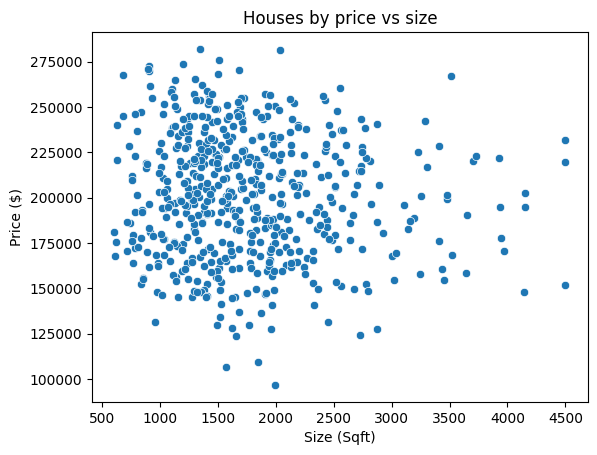

In [3]:
sns.scatterplot(data= df, x= "size", y= "price")
plt.title("Houses by price vs size")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

#### 2. Recreate the plot with neighborhood added:

Text(0, 0.5, 'Price ($)')

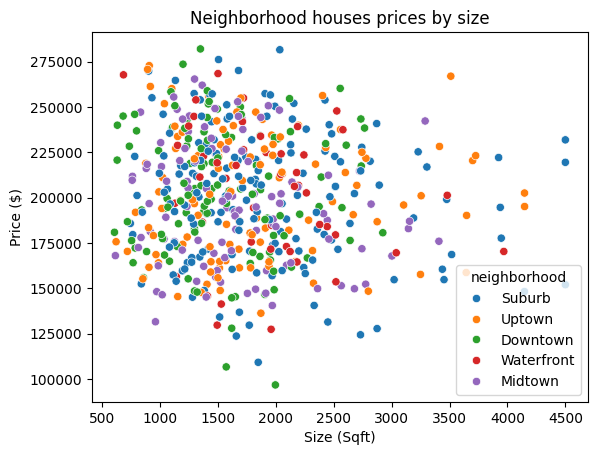

In [4]:
sns.scatterplot(data = df, x = "size", y = "price", hue = "neighborhood")
plt.title("Neighborhood houses prices by size")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

#### 3. Recreate the plot using color = neighborhood (use seaborn).

Text(0, 0.5, 'Price ($)')

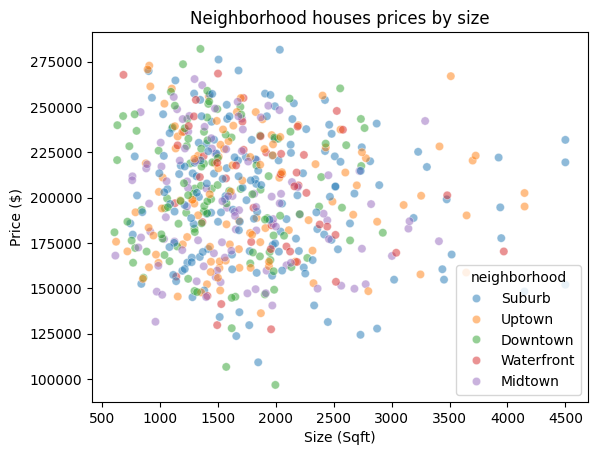

In [5]:
sns.scatterplot(data = df, x = "size", y = "price", hue = "neighborhood", alpha = 0.5)
plt.title("Neighborhood houses prices by size")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

## Short Answer (3--4 sentences)
#### What does seaborn automatically handle that matplotlib does not?
#### Why is transparency useful here?

##### Seaborn allows colors to be added and data to be grouped together. In this scatter plot the data points have been grouped by neighborhood. Matplotlib is used to add the axis labels and the title. Since many of the points are on top of each other the transparency is used to help overlapping points be seen more clearly.

## B. Small Multiples (Faceting)
#### Create small multiples of size vs price, separated by bedrooms.

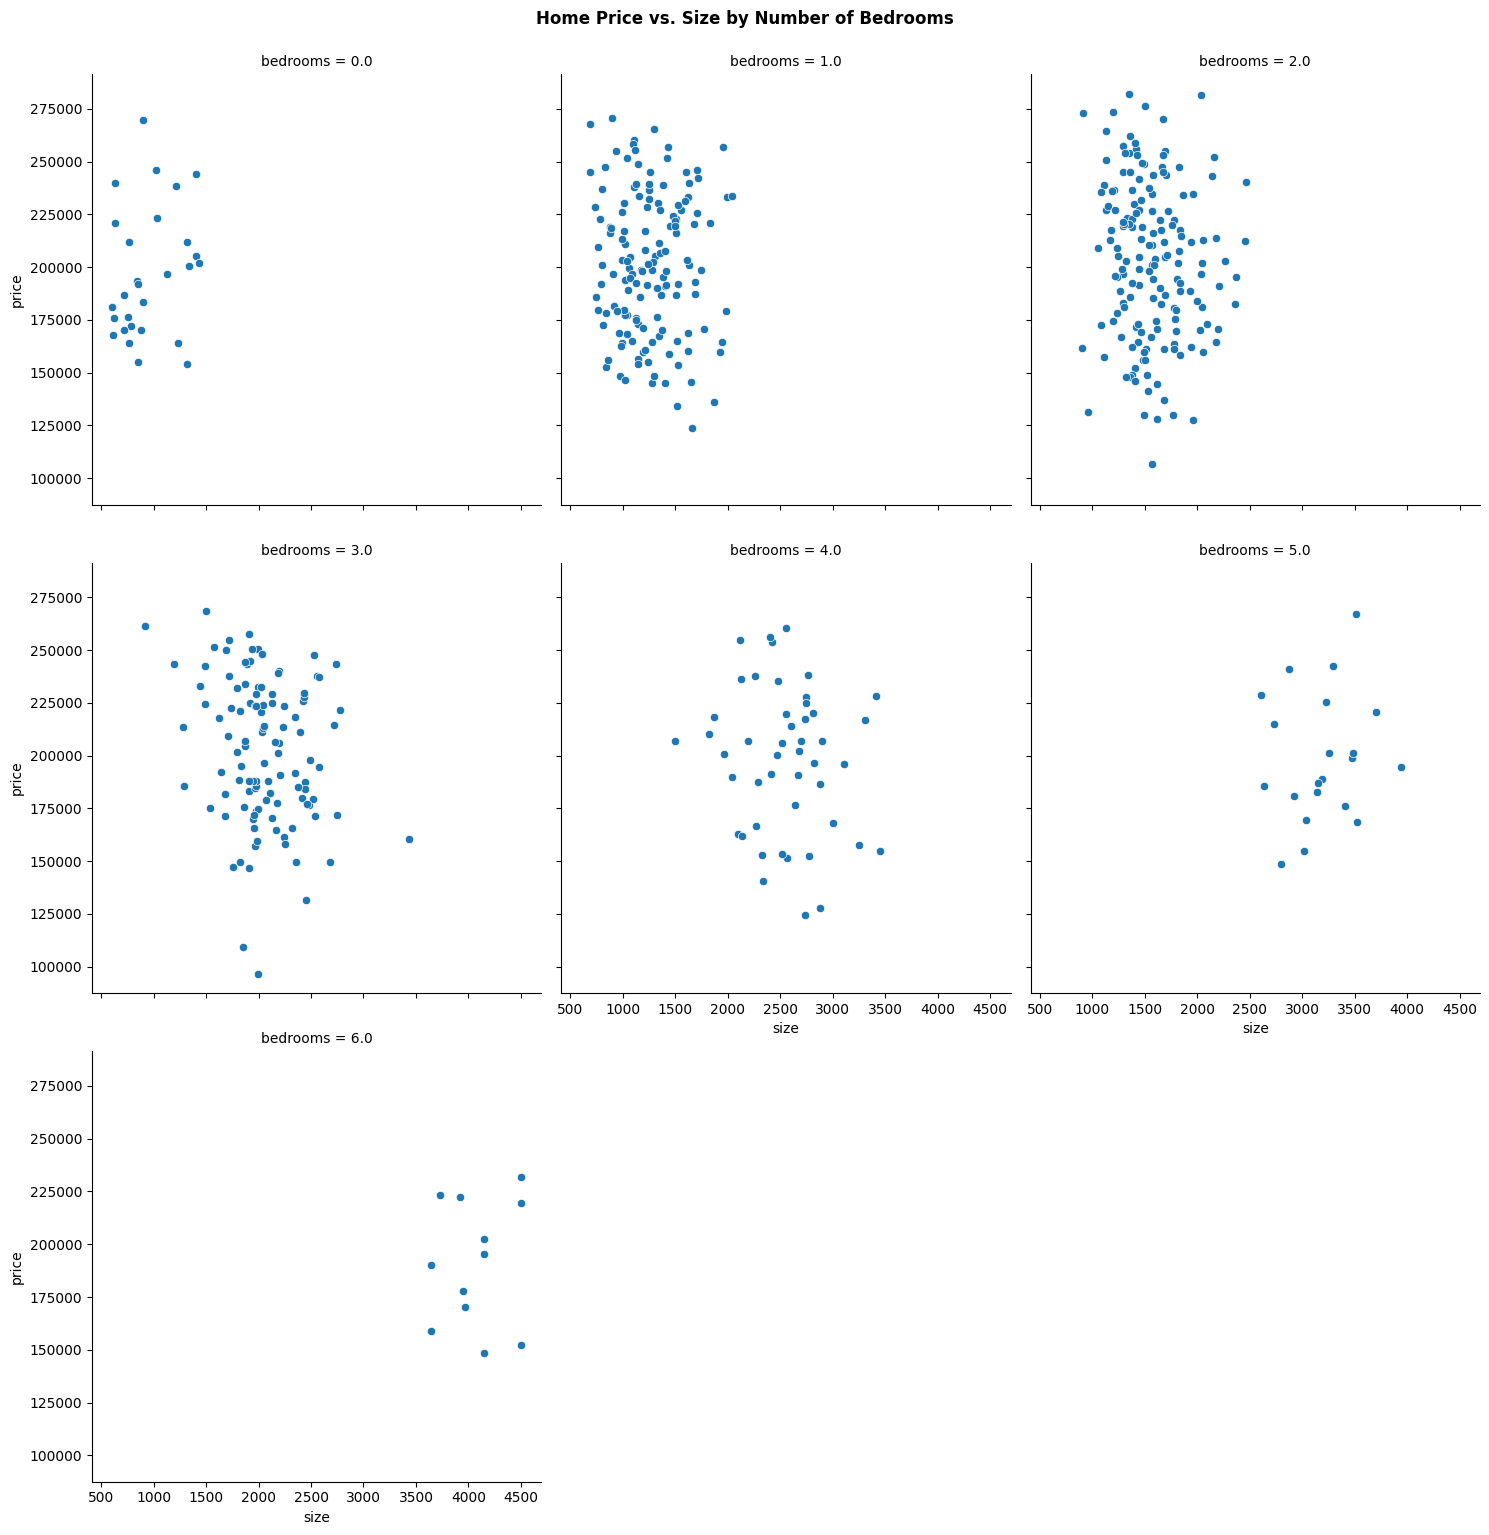

In [6]:
sns.relplot(data = df, x = "size", y = "price" , col = "bedrooms", col_wrap = 3)
plt.suptitle("Home Price vs. Size by Number of Bedrooms", y = 1.02, fontweight = "bold")
plt.show()

### Does the relationship between size and price look similar across bedroom counts?

#### the size of the house does increase as the number of bedrooms increase, thought there is no clear correlation between size and price.

# C. Distribution and Categorical Plots
#### 1. Create a histogram of price.

Text(0, 0.5, 'Number of houses')

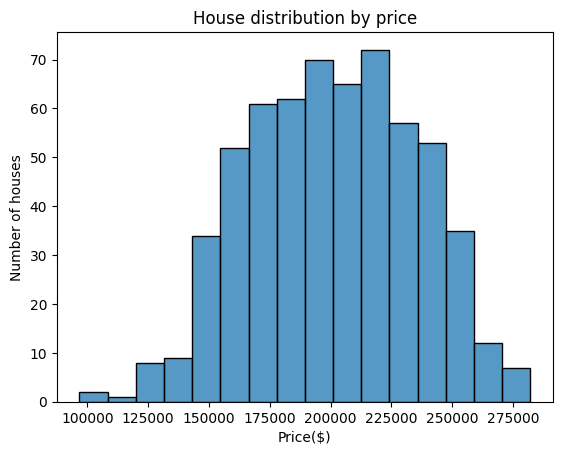

In [7]:
sns.histplot(data= df, x= "price")
plt.title("House distribution by price")
plt.xlabel("Price($)")
plt.ylabel("Number of houses")

### 2. Create a density plot of price.

Text(0, 0.5, 'Density')

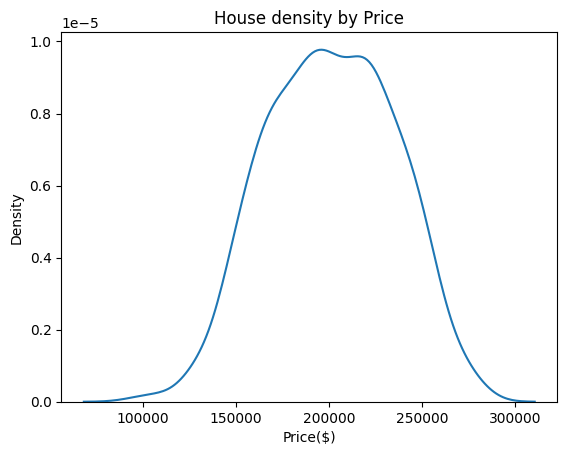

In [8]:
sns.kdeplot(data= df, x= "price")
plt.title("House density by Price")
plt.xlabel("Price($)")
plt.ylabel("Density")

### 3. Create a boxplot of price by neighborhood.

Text(0, 0.5, 'Price($)')

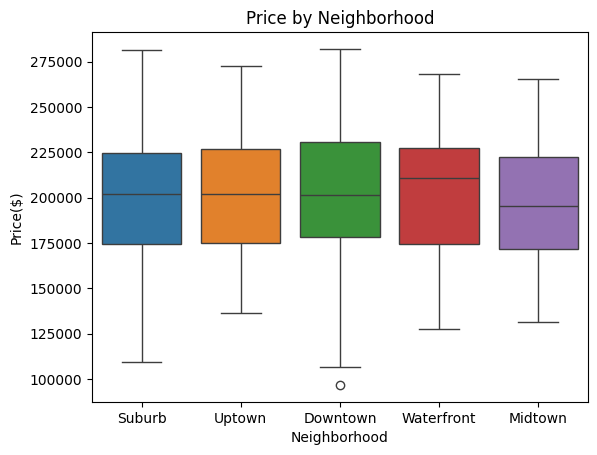

In [9]:

sns.boxplot(data= df, x= "neighborhood", y= "price", hue = "neighborhood")
plt.title("Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price($)")

## Interpretation (short paragraph)
###  Do neighborhoods differ systematically in price?
### What visual evidence supports your claim?

#### The median price for four of the neighborhoods, not including Waterfront, is roughly around $200,000. Downtown and Suburb show the largest spread in prices, with Downtown also having an outlier. Waterfront appears to be slightly leftskewed. Overall, housing prices across the neighborhoods seem for the most part similar

# Part II -- Linear Regression for Inference (30 pts)
## A. Multiple Regression (R → Python)
### In R, the model would be:

> lm(price ~ size + bedrooms + neighborhood, data = df)

### In Python:

In [11]:
model_housing = smf.ols("price ~ size + bedrooms + neighborhood", data = df).fit()
model_housing.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.190
Time:                        00:15:46   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
neighborhood[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
neighborhood[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
neighborhood[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
neighborhood[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                         -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                    4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Interpret the coefficient on size, explicitly stating what is being held constant.
#### Is size statistically significant? How do you know?
#### What does R² tell us in this context?

#### The coefficient for size is -10.935, which means each additional square foot decreases the homes price by about $10.94 when other variables are held constant. Although this is statistically significant (p = 0.01), though it may suggest issues with the data. The model is also very weak, only 1.7% of the variation in home prices.

# Part III -- Prediction Workflow (20 pts)

In [12]:
df= df.dropna()
df.isna().sum()

,0
listing_id,0
price,0
size,0
bedrooms,0
neighborhood,0
type,0


In [13]:
X = df[["size", "bedrooms", "neighborhood"]]
y = df["price"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=30)

model= LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
R2 = r2_score(y_test, y_pred)

print(rmse)
print(R2)

36790.16202375099
-0.01806791194992874


# Short Answer
## Why does scikit-learn not report p-values?

### Scikit-learn is mainly used for prediction, while statsmodels is used for statistical inference. Statsmodels helps explain relationships between variables using coefficients and p-values, whereas scikit-learn focuses on predicting future data.

Text(0, 0.5, 'Price ($)')

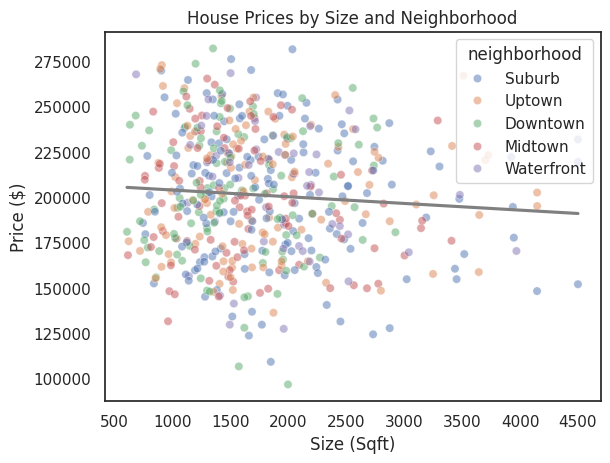

In [20]:
sns.scatterplot(data= df, x= "size", y= "price", hue= "neighborhood", alpha= 0.5)
sns.regplot(data= df, x= "size", y= "price", scatter= False, color = "gray", ci = None)
plt.title("House Prices by Size and Neighborhood")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

# Part IV -- Integrated Thinking (10 pts)
### Create one polished figure that:

### The linear regression model has a low R-squared of 0.017 and a coefficient of -10.9345, showing a weak negative relationship between home price and size. The plot confirms this, with a downward regression line and widely scattered data points.